# Bell State Preparation experiment: Compute $\langle \bar{\Phi}^+ | \bar{Z}\bar{Z} | \bar{\Phi}^+\rangle$ with the seven-qubit Steane code

In [1]:
from typing import List, Dict, Sequence
import itertools
import functools
import numpy as np
from tqdm import tqdm
import cirq
import qiskit
from qiskit.circuit.library import Barrier
import qiskit_ibm_runtime
from qiskit_ibm_runtime import SamplerV2 as Sampler

import stim
import stimcirq

from encoded.diagonalize import string_to_cirq_paulistring
from encoded.tcc import get_stabilizer_generators, tcc_encoding

/Users/ryan/prof/work/encoded/envencoded/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


## Set parameters

In [2]:
d = 7                                   # Code distance.
nshots = 10_000                         # Number of samples/shots
depth = 0                               # Number of folded Bell state preparation circuits for added noise
k = 2                                   # Number of logical qubits.
observable: str = "ZZ"                  # (Logical) observable to measure. Either XX or ZZ.

In [3]:
distance_to_nqubits = lambda d: (3 * d ** 2 + 1) // 4

n = distance_to_nqubits(d)
n

37

In [ ]:
# Computer and qubits to use.

computer = service.backend("ibm_boston")
sampler = Sampler(computer)

# See calibration data at https://quantum.ibm.com/services/resources to select good qubits.
layout = {
    1: [2, 3],
    3: [29, 30, 31, 32, 33, 38, 39, 48, 49, 50, 51, 52, 53, 54],
    5: list(range(38)),  # TODO: Update.
}

# The best qubits ever on Fez Feb 6-8.
# layout = {
#     1 : [123, 124],
#     7 : [123, 124, 125, 126, 127, 128, 136, 137, 142, 143, 144, 145, 146, 147],
# }


# Good on Kyiv 2/6
# layout = {
#     1 : [20, 21],
#     7 : [0, 1, 2, 3, 4, 5, 14, 15, 18, 19, 20, 21, 22, 23],
# }

# Good on Sherbrooke 2/5.
# layout = {
#     1 : [103, 104],
#     7 : [103, 104, 105, 106, 107, 108, 111, 112, 121, 122, 123, 124, 125, 126],
# }

# Good on Kyiv 2/5.
# layout = {
#     1 : [95, 96],
#     7 : [95, 96, 97, 98, 99, 100, 101, 113, 114, 115, 116, 117, 118, 119],
# }

qiskit_runtime_service._discover_account:WARNING:2026-04-12 22:49:50,463: Loading account with the given token. A saved account will not be used.


In [5]:
len(layout[d])

38

In [19]:
create_hex_grid?

Signature:
create_hex_grid(
    nx: int = 4,
    ny: int = 5,
    min_diam: float = 1.0,
    n: int = 0,
    align_to_origin: bool = True,
    face_color: Union[List[float], str] = None,
    edge_color: Union[List[float], str] = None,
    plotting_gap: float = 0.0,
    crop_circ: float = 0.0,
    do_plot: bool = False,
    rotate_deg: float = 0.0,
    keep_x_sym: bool = True,
    h_ax: matplotlib.axes._axes.Axes = None,
    line_width: float = 0.2,
    background_color: Union[List[float], str] = None,
) -> (<class 'numpy.ndarray'>, <class 'matplotlib.axes._axes.Axes'>)
Docstring:
Creates and prints hexagonal lattices.
:param nx: Number of horizontal hexagons in rectangular grid, [nx * ny]
:param ny: Number of vertical hexagons in rectangular grid, [nx * ny]
:param min_diam: Minimal diameter of each hexagon.
:param n: Alternative way to create rectangular grid. The final grid might have less hexagons
:param align_to_origin: Shift the grid s.t. the central tile will center at the origin


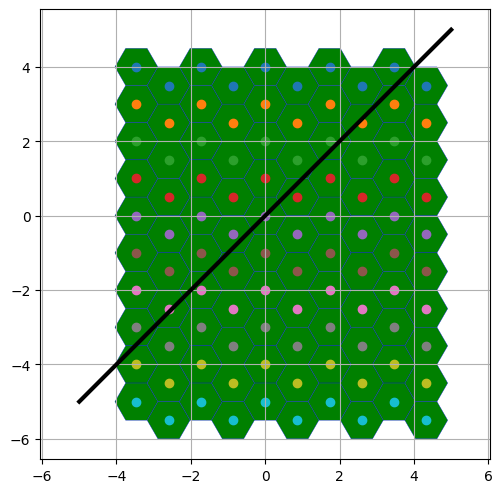

In [35]:
# Installation: pip install hexalattice
from hexalattice.hexalattice import create_hex_grid
import matplotlib.pyplot as plt
hex_centers, _ = create_hex_grid(nx=10, ny=10, align_to_origin=True, rotate_deg=90, face_color="g", edge_color="b", do_plot=True)

for center in hex_centers:
    plt.scatter(*center)

xs = np.linspace(-5, 5, 100)
plt.plot(xs, xs, color="black", lw=3)
plt.axis("equal")
plt.grid()
plt.show();

In [70]:
import dataclasses


@dataclasses.dataclass
class Tile:
    qubits: list
    color: str


def make_color_code_tiles(*, base_data_width):
    if not (base_data_width % 2 == 1 and base_data_width >= 3):
        raise ValueError(f"{base_data_width=} wasn't an odd number at least as large as 3.")
    w = base_data_width * 2 - 1

    def is_in_bounds(q: complex) -> bool:
        if q.imag < 0:
            return False
        if q.imag * 2 > q.real * 3:
            return False
        if q.imag * 2 > (w - q.real) * 3:
            return False
        return True

    tiles = []
    hexagon_offsets = [-1, +1j, +1j + 1, +2, -1j + 1, -1j]
    for x in range(1, w, 2):
        for y in range((x // 2) % 2, w, 2):
            q = x + 1j * y

            tile = Tile(
                color=["red", "green", "blue"][y % 3],
                qubits=[q + d for d in hexagon_offsets if is_in_bounds(q + d)],
            )

            if len(tile.qubits) in [4, 6]:
                tiles.append(tile)

    return tiles


def get_stabilizer_generators(distance: int):
    tiles = make_color_code_tiles(base_data_width=distance)
    all_qubits = {q for tile in tiles for q in tile.qubits}

    # Only difference here is with the chromobius notebook that we rever
    sorted_qubits = sorted(all_qubits, key=lambda q: (q.imag, q.real))
    q2i = {q: i for i, q in enumerate(sorted_qubits)}

    sorted_tiles = []
    for tile in tiles:
        sorted_tiles.append([q2i[q] for q in tile.qubits])

    stabilizers_x = []
    stabilizers_z = []
    for tile in sorted_tiles:
        stab_x = ""
        stab_z = ""
        for i in range(int((3 * distance ** 2 + 1) / 4)):
            if i in tile:
                stab_x += "X"
                stab_z += "Z"
            else:
                stab_x += "I"
                stab_z += "I"
        stabilizers_x.append(stab_x)
        stabilizers_z.append(stab_z)

    return stabilizers_x + stabilizers_z

In [71]:
make_color_code_tiles(base_data_width=3)

[Tile(qubits=[0j, (1+1j), (2+1j), (3+0j)], color='red'),
 Tile(qubits=[(2+3j), (3+2j), (2+1j), (1+1j)], color='blue'),
 Tile(qubits=[(2+1j), (3+2j), (4+0j), (3+0j)], color='green')]

In [72]:
get_stabilizer_generators(distance=3)

['XXIXXII', 'IIIXXXX', 'IXXIXXI', 'ZZIZZII', 'IIIZZZZ', 'IZZIZZI']

In [64]:
color_code(3)

qubits: 7 expected: 7
# stabilizers: 1


([(-1, 0), (-1, 1), (0, -1), (0, 0), (0, 1), (1, -1), (1, 0)],
 [(0, 1), (3, 4), (0, 3), (1, 4), (2, 3), (5, 6), (3, 6), (2, 5)],
 [(0, 1, 2, 4, 5, 6)],
 array([[1, 1, 1, 0, 1, 1, 1]]),
 array([[1, 1, 1, 0, 1, 1, 1]]))

In [55]:
zstabs

array([[1, 1, 1, 0, 1, 1, 1]])

In [16]:
get_stabilizer_generators(3)

['IIXXIXX', 'XXXXIII', 'IXXIXXI', 'IIZZIZZ', 'ZZZZIII', 'IZZIZZI']

In [6]:
# Expectation of pauli on bitstring measured in diagonal basis.
def compute_expectation(
    pauli: cirq.PauliString,
    counts: Dict[str, int],
) -> float:
    if pauli is cirq.PauliString():
        return 1.0

    expectation = 0.0

    indices = [q.x for q in pauli.qubits]
    for key, value in counts.items():
        key = list(map(int, list(key[::-1])))
        expectation += (-1) ** sum([key[i] for i in indices]) * value

    return pauli.coefficient * expectation / sum(counts.values())

### Run unmitigated experiment

In [ ]:
qreg = cirq.LineQubit.range(k)

circuit = cirq.Circuit()
circuit.append(cirq.H.on(qreg[0]))
for i in range(len(qreg)-1):
    circuit.append(cirq.CNOT.on(qreg[i], qreg[i+1]))

circuit = qiskit.QuantumCircuit.from_qasm_str(circuit.to_qasm())

# Idle time/X gates.
for _ in range(depth):
    circuit.x(circuit.qubits)
    circuit.barrier()
    circuit.x(circuit.qubits)
    circuit.barrier()

if observable == "XX":
    circuit.h(circuit.qubits)

circuit.measure_active()
# Compile to device.
compiled_physical = qiskit.transpile(
    circuit, 
    backend=computer,
    initial_layout=layout[1],  # Hardcode n = 1 (i.e., no encoding) to get layout.
    routing_method="sabre",
    # scheduling_method="asap",
    optimization_level=0,
)
print(compiled_physical.draw(fold=-1, idle_wires=False))

In [ ]:
job_physical = sampler.run(
    [compiled_physical],
    shots=nshots,
)

In [ ]:
all_counts_raw = [result.data.meas.get_counts() for result in job_physical.result()]
all_counts_raw

In [ ]:
ev_physical = compute_expectation(string_to_cirq_paulistring("ZZ"), all_counts_raw[0])
print("Physical result:", ev_physical)

## Run encoded experiment

### Compute/load 0_L / 1_L bitstrings

In [11]:
encode_circuit = tcc_encoding(d)
# encode_circuit = cirq.H.on_each(encode_circuit.all_qubits()) + encode_circuit[1:]
# encode_circuit.append(cirq.X.on_each(encode_circuit.all_qubits()))
encode_circuit

┌──┐                       ┌──┐                   ┌──┐           ┌──┐                               ┌──┐           ┌──┐                       ┌──┐       ┌──┐           ┌──┐                           ┌──┐               ┌──┐       ┌──┐           ┌──┐   ┌──┐                       ┌──┐           ┌──┐           ┌──┐                   ┌──┐
0: ────X───@───X───X───X───X───X───X───X────X────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       │   │   │   │   │   │   │   │   │    │
1: ────┼───┼───┼───@───┼───┼───┼───┼───┼────┼X────X───X───X───X───X────X─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       │   │   │       │   │   │   │   │    ││    │   │   │   │   │    │
2: ────┼───┼───┼───────@───┼───┼───┼───┼────┼@────┼───┼───┼───┼───┼────┼X────@───X───@───X────X──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       │   │   │           │   │   │   │    │     │   │   │   │   │    ││    │   │   │   │    │
3: ────┼───┼───┼───────────┼───┼───┼───┼────┼─────┼───┼───┼───┼───┼────┼┼────┼───┼───┼───┼────┼X────@───X────X───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       │   │   │           │   │   │   │    │     │   │   │   │   │    ││    │   │   │   │    ││    │   │    │
4: ────@───X───@───────────@───┼───┼───┼────┼─────@───┼───┼───┼───┼────┼┼────┼───┼───┼───┼────┼┼────┼───┼────┼X────@───X───X───X───X───X───X────X────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                               │   │   │    │         │   │   │   │    ││    │   │   │   │    ││    │   │    ││    │   │   │   │   │   │   │    │
5: ────────────────────────────┼───┼───┼────┼─────────┼───┼───┼───┼────┼┼────┼───┼───X───┼────┼┼────┼───┼────┼┼────┼───┼───@───┼───┼───┼───┼────┼X────X───X────X─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                               │   │   │    │         │   │   │   │    ││    │   │       │    ││    │   │    ││    │   │       │   │   │   │    ││    │   │    │
6: ────────────────────────────@───┼───┼────┼─────────@───┼───┼───┼────┼┼────┼───┼───────┼────┼┼────┼───┼────┼┼────┼───┼───────┼───┼───┼───┼────┼@────┼───┼────┼X────@───X───X───X───X────X──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                   │   │    │             │   │   │    ││    │   │       │    ││    │   │    ││    │   │       │   │   │   │    │     │   │    ││    │   │   │   │   │    │
7: ────────────────────────────────┼───┼────┼─────────────┼───┼───┼────┼┼────┼───┼───────┼────┼┼────┼───┼────┼┼──

In [12]:
s = stimcirq.cirq_circuit_to_stim_circuit(encode_circuit + cirq.measure(encode_circuit.all_qubits())).compile_sampler()

In [13]:
print(sorted(set([int(b[0]) for b in s.sample(10_000_000, bit_packed=True)])))

[0, 6, 9, 15, 19, 21, 26, 28, 35, 37, 42, 44, 48, 54, 57, 63, 64, 70, 73, 79, 83, 85, 90, 92, 99, 101, 106, 108, 112, 118, 121, 127, 128, 134, 137, 143, 147, 149, 154, 156, 163, 165, 170, 172, 176, 182, 185, 191, 192, 198, 201, 207, 211, 213, 218, 220, 227, 229, 234, 236, 240, 246, 249, 255]


In [ ]:
try:
    zero_bitstrings = np.loadtxt(f"zero_bitstrings_d{d}.txt")
    print("Loaded zero bitstrings (ints) from memory:", zero_bitstrings)
except FileNotFoundError:
    print(f"Unable to load zero bitstrings for distance {d} from memory, computing them...")
    encode_circuit = tcc_encoding(d)
    encode_circuit = cirq.H.on_each(encode_circuit.all_qubits()) + encode_circuit[1:]  # Remove RX gates to prepare the |+> state in favor of H.
    s = stimcirq.cirq_circuit_to_stim_circuit(encode_circuit + cirq.measure(encode_circuit.all_qubits())).compile_sampler()
    zero_bitstrings = sorted(set([int(b[0]) for b in s.sample(10_000_000, bit_packed=True)]))
    print("Computed these bitstrings (ints) and saved to memory:", zero_bitstrings)
    np.savetxt(f"zero_bitstrings_d{d}.txt", zero_bitstrings)

try:
    one_bitstrings = np.loadtxt(f"one_bitstrings_d{d}.txt")
    print("Loaded one bitstrings (ints) from memory:", one_bitstrings)
except FileNotFoundError:
    print(f"Unable to load one bitstrings for distance {d} from memory, computing them...")
    encode_circuit = tcc_encoding(d)
    encode_circuit = cirq.H.on_each(encode_circuit.all_qubits()) + encode_circuit[1:]  # Remove RX gates to prepare the |+> state in favor of H.
    encode_circuit.append(cirq.X.on_each(encode_circuit.all_qubits()))  # Put into 1_L state.
    s = stimcirq.cirq_circuit_to_stim_circuit(encode_circuit + cirq.measure(encode_circuit.all_qubits())).compile_sampler()
    one_bitstrings = sorted(set([int(b[0]) for b in s.sample(1_000_000, bit_packed=True)]))
    print("Computed these bitstrings (ints) and saved to memory:", one_bitstrings)
    np.savetxt(f"one_bitstrings_d{d}.txt", one_bitstrings)

### Unit tests

In [ ]:
# Get circuit to encode |0_L 0_L>.
encode_circuit = tcc_encoding(d)  # Encodes one |0_L>.
encode_circuit = cirq.H.on_each(encode_circuit.all_qubits()) + encode_circuit[1:]  # Remove RX gates to prepare the |+> state in favor of H.

qreg = cirq.LineQubit.range(n * k)
encoding = cirq.Circuit.concat_ragged(
    encode_circuit,
    encode_circuit.transform_qubits({a: b for a, b in zip(qreg[:n], qreg[n:])})
)
# Test that preparing |0_L 0_L> always measures |0_L> on both qubits.
test = encoding.copy()
result = cirq.Simulator().run(test + cirq.measure(test.all_qubits(), key="z"), repetitions=10_000)
bitstrings = result.measurements.get("z")

for bitstring in bitstrings:
    q0 = int("".join(str(s) for s in bitstring[:n][::-1]), 2)
    q1 = int("".join(str(s) for s in bitstring[n:][::-1]), 2)
    assert q0 in zero_bitstrings
    assert q1 in zero_bitstrings

# Test that preparing |0_L 1_L> always measures |0_L> on the first qubit and |1_L> on the second qubit.
test = encoding.copy()
test.append(cirq.X.on_each(qreg[n:]))
result = cirq.Simulator().run(test + cirq.measure(test.all_qubits(), key="z"), repetitions=10_000)
bitstrings = result.measurements.get("z")

for bitstring in bitstrings:
    q0 = int("".join(str(s) for s in bitstring[:n][::-1]), 2)
    q1 = int("".join(str(s) for s in bitstring[n:][::-1]), 2)
    assert q0 in zero_bitstrings
    assert q1 in one_bitstrings
encoding.append(cirq.X.on_each(qreg[:n]))

# Test that preparing |+_L 0_L> measures |0_L> or |1_L> on the first qubit and |0_L> on the second qubit.
test = encoding.copy()
test.append(cirq.H.on_each(qreg[:n]))
result = cirq.Simulator().run(test + cirq.measure(test.all_qubits(), key="z"), repetitions=10_000)
bitstrings = result.measurements.get("z")

for bitstring in bitstrings:
    q0 = int("".join(str(s) for s in bitstring[:n][::-1]), 2)
    q1 = int("".join(str(s) for s in bitstring[n:][::-1]), 2)
    assert q0 in zero_bitstrings or q0 in one_bitstrings
    assert q1 in zero_bitstrings
encoding.append(cirq.X.on_each(qreg[:n]))

### Run experiment

In [ ]:
encode_circuit = tcc_encoding(d)
qubits = sorted(encode_circuit.all_qubits())
encode_circuit = cirq.H.on_each(qubits) + encode_circuit[1:]  # Remove RX gates to prepare the |+> state in favor of H.

qreg = cirq.LineQubit.range(n * k)
encoding = cirq.Circuit.concat_ragged(
    encode_circuit,
    encode_circuit.transform_qubits({a: b for a, b in zip(qreg[:n], qreg[n:])})
)
encoding.append(cirq.X.on_each(qreg[:n]))

# Prepare Bell state
encoding.append(cirq.Moment(cirq.H.on_each(qreg[:n])))
encoding.append(cirq.CNOT.on_each([(qreg[i], qreg[i+n]) for i in range(n)]))
encoding

In [ ]:
# Test only 0_L 0_L or 1_L 1_L are measured.
result = cirq.Simulator().run(encoding + cirq.measure(encoding.all_qubits(), key="z"), repetitions=10_000)
bit_arrays = result.measurements.get("z")

for bitstring in bit_arrays:
    q0 = int("".join(str(s) for s in bitstring[:n][::-1]), 2)
    q1 = int("".join(str(s) for s in bitstring[n:][::-1]), 2)
    if q0 in zero_bitstrings:
        assert q1 in zero_bitstrings
    elif q0 in one_bitstrings:
        assert q1 in one_bitstrings
    else:
        raise AssertionError("Neither 0_L 0_L nor 1_L 1_L were measured.")

In [ ]:
encoding = qiskit.QuantumCircuit.from_qasm_str(encoding.to_qasm())
encoding.draw(fold=-1)

In [ ]:
to_run = encoding.copy()
to_run.barrier()

# Idle time/X gates.
for _ in range(depth):
    to_run.x(to_run.qubits)
    to_run.barrier()
    to_run.x(to_run.qubits)
    to_run.barrier()

if observable == "XX":
    to_run.h(to_run.qubits)

to_run.measure_all()

to_run.draw(fold=-1)

In [ ]:
to_run = qiskit.transpile(
    to_run, 
    backend=computer,
    initial_layout=layout[d],
    routing_method="sabre",
    # scheduling_method="asap",
    optimization_level=3,
)
to_run.draw(fold=-1, idle_wires=False)

In [ ]:
# Test only 0_L 0_L or 1_L 1_L are measured (after conversion to Qiskit and endian-nonsense).
from qiskit_aer import AerSimulator

if observable == "ZZ":
    job = AerSimulator().run(to_run, shots=nshots)
    res = job.result()

    for bitstring in res.get_counts().keys():
        q0 = int("".join(str(s) for s in bitstring[:n][::]), 2)  # NOTE: Endianess.
        q1 = int("".join(str(s) for s in bitstring[n:][::]), 2)  # NOTE: Endianess.
        if q0 in zero_bitstrings:
            assert q1 in zero_bitstrings
        elif q0 in one_bitstrings:
            assert q1 in one_bitstrings
        else:
            raise AssertionError("Neither 0_L 0_L nor 1_L 1_L were measured.")

In [ ]:
to_run.count_ops()

In [ ]:
nshots

In [ ]:
job = sampler.run(
    [to_run],
    shots=nshots,
)

In [ ]:
all_counts = [result.data.meas.get_counts() for result in job.result()]
all_counts

In [ ]:
expval: float = 0.0
num_noncodewords = 0
for bitstring, count in all_counts[0].items():
    q0 = int("".join(str(s) for s in bitstring[:n][::]), 2)  # NOTE: Endianess.
    q1 = int("".join(str(s) for s in bitstring[n:][::]), 2)  # NOTE: Endianess.
    if q0 in zero_bitstrings and q1 in zero_bitstrings:
        expval += count
    elif q0 in zero_bitstrings and q1 in one_bitstrings:
        expval -= count
    elif q0 in one_bitstrings and q1 in zero_bitstrings:
        expval -= count
    elif q0 in one_bitstrings and q1 in one_bitstrings:
        expval += count
    else:
        num_noncodewords += count

In [ ]:
num_noncodewords

In [ ]:
num_codewords = nshots - num_noncodewords
num_codewords

In [ ]:
expval / num_codewords

## With DD

In [ ]:
sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = "XpXm"

In [ ]:
job_dd = sampler.run(
    [to_run],
    shots=nshots,
)

In [ ]:
all_counts_dd = [result.data.meas.get_counts() for result in job_dd.result()]
all_counts_dd

In [ ]:
expval_dd: float = 0.0
num_noncodewords_dd = 0
for bitstring, count in all_counts_dd[0].items():
    q0 = int("".join(str(s) for s in bitstring[:n][::]), 2)  # NOTE: Endianess.
    q1 = int("".join(str(s) for s in bitstring[n:][::]), 2)  # NOTE: Endianess.
    if q0 in zero_bitstrings and q1 in zero_bitstrings:
        expval_dd += count
    elif q0 in zero_bitstrings and q1 in one_bitstrings:
        expval_dd -= count
    elif q0 in one_bitstrings and q1 in zero_bitstrings:
        expval_dd -= count
    elif q0 in one_bitstrings and q1 in one_bitstrings:
        expval_dd += count
    else:
        num_noncodewords_dd += count

In [ ]:
num_codewords_dd = nshots - num_noncodewords_dd
num_codewords_dd

In [ ]:
expval_dd / num_codewords_dd

## Save results

In [ ]:
import os
import pickle

In [ ]:
import datetime


time_key = datetime.datetime.now().strftime("%m_%d_%Y_%H:%M:%S")  # For saving results.

In [ ]:
save_key = f"bell_tcc_distance_{d}_{observable}_depth_{depth}_{computer.name}_{time_key}_job_raw_id_{job_physical.job_id()}_job_encoded_id_{job.job_id()}_job_encoded_dd_id_{job_dd.job_id()}"
save_key

In [ ]:
os.mkdir(save_key)

In [ ]:
pickle.dump(all_counts_raw, open(f"{save_key}/all_counts_raw.pkl", "wb"))
pickle.dump(all_counts, open(f"{save_key}/all_counts.pkl", "wb"))
pickle.dump(all_counts_dd, open(f"{save_key}/all_counts_dd.pkl", "wb"))

In [ ]:
np.savetxt(f"{save_key}/qubits_physical.txt", layout[1])
np.savetxt(f"{save_key}/qubits_encoded.txt", layout[d])

In [ ]:
np.savetxt(f"{save_key}/nshots.txt", [nshots])

In [ ]:
np.savetxt(f"{save_key}/physical.txt", [ev_physical])
np.savetxt(f"{save_key}/encoded.txt", [expval])
np.savetxt(f"{save_key}/encoded_dd.txt", [expval_dd])